In [63]:
import sys
import os
import importlib

#--------------------------------------------------------------
# clearing cache so that the core.py is called from the right place, had issue earlier
modules_to_clear = [
    m for m in sys.modules.keys() 
    if any(p in m for p in ["models", "src", "data", "metrics"])
]
for module in modules_to_clear:
    del sys.modules[module]
PROJECT_ROOT = "/Users/darya/Desktop/Diploma/COMPAS - criminals/whole_process"
sys.path = [p for p in sys.path if "COMPAS - criminals" not in p]
sys.path.insert(0, PROJECT_ROOT)
cox_upd_path = os.path.join(PROJECT_ROOT, "models", "cox_model_upd.py")
spec = importlib.util.spec_from_file_location("cox_model_upd", cox_upd_path)
cox_model_upd = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cox_model_upd)
CoxModelUpd = cox_model_upd.CoxModelUpd
#issue with the ibs_metric part because of numba, i beleive this helped fix it
os.environ["NUMBA_DISABLE_JIT"] = "1"
#--------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from data.data_processor import DataProcessor
from data.splitter import SurvivalSplitter
from models.cox_model import CoxModel
from models.cox_model_upd import CoxModelUpd
from metrics.ibs import IBSMetric
from metrics.ibs_remain import IBSRemainMetric
from metrics.auprc import AUPRCMetric
from metrics.recurrent_count_error import RecurrentCountError
from pipeline.evaluator import SurvivalEvaluator
from survivors.constants import get_y

In [64]:
df = pd.read_csv('data/individual_custody_timeline_rfm.csv')
print(df.columns)

Index(['name', 'age', 'sex', 'race', 'c_charge_degree', 'c_charge_desc',
       'in_custody', 'out_custody', 'custody_num', 'time_to_last_custody',
       'time_since_last_arrest', 'time_to_future_arrest', 'event',
       'event_of_future_arrest', 'curr_dur_custody', 'sum_dur_custody',
       'average_dur_custody', 'all_future_arrest_times', 'all_future_events'],
      dtype='object')


In [65]:
df

,name,age,sex,race,c_charge_degree,c_charge_desc,in_custody,out_custody,custody_num,time_to_last_custody,time_since_last_arrest,time_to_future_arrest,event,event_of_future_arrest,curr_dur_custody,sum_dur_custody,average_dur_custody,all_future_arrest_times,all_future_events
0,aajah herrington,23,Female,African-American,(F3),Driving While License Revoked,2013-04-23,2013-04-24,1,NaN,NaN,385.0,1,1,1.0,0,NaN,[385],"[1, 0]"
1,aajah herrington,23,Female,African-American,(F3),Driving While License Revoked,2014-05-13,2014-06-05,2,385.0,384.0,NaN,0,0,23.0,1,1.0,NaN,[0]
2,aaliyah lovo,21,Female,Caucasian,(F2),Burglary Unoccupied Dwelling,2013-11-03,2013-11-05,1,NaN,NaN,NaN,0,0,2.0,0,NaN,NaN,[0]
3,aaron aprile,27,Male,Hispanic,(F3),Grand Theft in the 3rd Degree,2014-06-06,2014-07-31,1,NaN,NaN,55.0,1,1,55.0,0,NaN,[55],"[1, 0]"
4,aaron aprile,27,Male,Hispanic,(F3),Grand Theft in the 3rd Degree,2014-07-31,2015-12-23,2,55.0,0.0,NaN,0,0,510.0,55,55.0,NaN,[0]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18663,zolya isale,21,Female,African-American,NaN,NaN,2014-12-23,2014-12-23,1,NaN,NaN,NaN,0,0,0.0,0,NaN,NaN,[0]
18664,zuberi floyd,22,Male,African-American,(F3),Uttering a Forged Instrument,2013-11-12,2013-11-13,1,NaN,NaN,757.0,1,1,1.0,0,NaN,[757],"[1, 0]"
18665,zuberi floyd,22,Male,African-American,(F3),Uttering a Forged Instrument,2015-12-09,2015-12-09,2,757.0,756.0,NaN,0,0,0.0,1,1.0,NaN,[0]
18666,zulimay lizcano,44,Female,Caucasian,(F3),Grand Theft in the 3rd Degree,2013-10-25,2013-10-26,1,NaN,NaN,NaN,0,0,1.0,0,NaN,NaN,[0]


In [66]:
# importlib.reload(data.data_processor)

processor = DataProcessor("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
'''cox_df = pd.get_dummies(
    cox_df,
    columns=["sex", "race"],
    drop_first=True
)'''
cox_df.head()

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,curr_dur_custody
0,aajah herrington,1,0.0,385.0,0,23,384.0,1.0,1.0
1,aaron aprile,1,0.0,55.0,0,27,0.0,55.0,55.0
2,aaron davis,1,0.0,432.0,0,41,314.0,118.0,118.0
3,aaron eddins,1,0.0,104.0,0,37,104.0,0.0,0.0
4,aaron epstein,1,0.0,297.0,1,22,296.0,1.0,1.0


Data split into train and test data

In [67]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [68]:
train_df["time"] = train_df["entry"] + train_df["dur"]
test_df["time"] = test_df["entry"] + test_df["dur"]

train_cens = train_df["event"].astype(bool)
test_cens = test_df["event"].astype(bool)

survival_train = get_y(
    cens=train_cens,
    time=train_df["time"],
    competing=False
)

survival_test = get_y(
    cens=test_cens,
    time=test_df["time"],
    competing=False
)


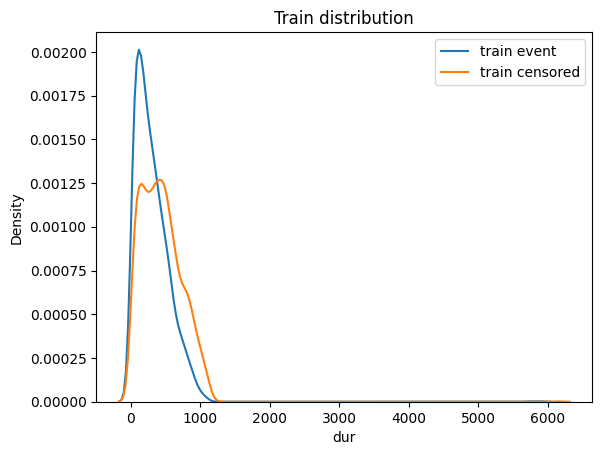

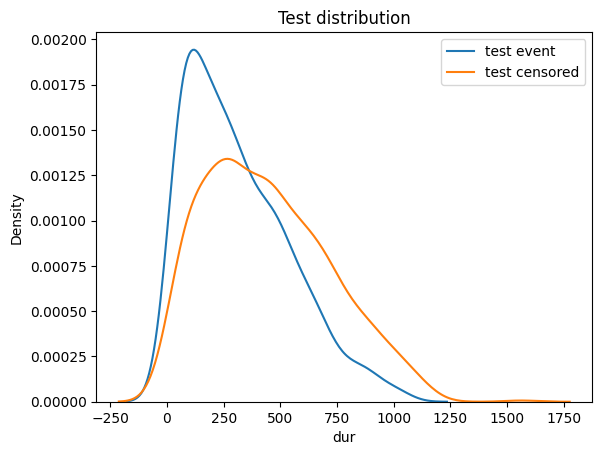

Train events: event
0    3382
1    2767
Name: count, dtype: int64
Test events: event
0    845
1    778
Name: count, dtype: int64


In [69]:
plt.figure()
sns.kdeplot(train_df[train_df["event"]==1]["dur"], label="train event")
sns.kdeplot(train_df[train_df["event"]==0]["dur"], label="train censored")
plt.legend()
plt.title("Train distribution")
plt.show()

plt.figure()
sns.kdeplot(test_df[test_df["event"]==1]["dur"], label="test event")
sns.kdeplot(test_df[test_df["event"]==0]["dur"], label="test censored")
plt.legend()
plt.title("Test distribution")
plt.show()

print("Train events:", train_df["event"].value_counts())
print("Test events:", test_df["event"].value_counts())


Using the original CoxModel file that I had (cox_model.py)

In [70]:
# importlib.reload(models.cox_model)

print(train_df.columns)

features = [c for c in train_df.columns 
            if c not in ["name", "entry", "time", "event", "dur", "episode_col"]]
print(features)

cols_for_model = ["name", "entry", "time", "event"] + features
train_model_df = train_df[cols_for_model].copy()


model = CoxModel(features=features)
model.fit(train_model_df)

Index(['name', 'episode_col', 'entry', 'dur', 'event', 'age',
       'time_since_last_arrest', 'average_dur_custody', 'time'],
      dtype='object')
['age', 'time_since_last_arrest', 'average_dur_custody']


model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
entry col,'entry'
cluster col,'name'
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-20405.07
time fit was run,2026-03-03 13:25:25 UTC


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


Using the updated CoxModelUpd file (cox_model_upd.py). RECURRENT WITH EPISODE_COL case

In [71]:
# RECURRENT WITH EPISODE_COL
features1 = [c for c in train_df.columns 
            if c not in ["name", "entry", "time", "event", "dur"]]

cols_for_model1 = ["name", "episode_col", "entry", "time", "event"] + \
                 [c for c in features if c != "episode_col"]

train_model_df1 = train_df[cols_for_model1].copy()

model1 = CoxModelUpd(
    features=[c for c in features1 if c != "episode_col"],
    mode="recurrent",
    use_episode=True
)

model1.fit(train_model_df1)


model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
entry col,'entry'
cluster col,'name'
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-16050.54


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


Using the updated CoxModelUpd file (cox_model_upd.py). RECURRENT WITHOUT EPISODE_COL case

In [72]:
# RECURRENT WITHOUT EPISODE_COL
features2 = [c for c in train_df.columns 
            if c not in ["name", "entry", "time", "event", "dur", "episode_col"]]

cols_for_model2 = ["name", "entry", "time", "event"] + features
train_model_df2 = train_df[cols_for_model2].copy()

model2 = CoxModelUpd(
    features=features2,
    mode="recurrent",
    use_episode=False
)
model2.fit(train_model_df2)

model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
entry col,'entry'
cluster col,'name'
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-20405.07
time fit was run,2026-03-03 13:25:27 UTC


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


Using the updated CoxModelUpd file (cox_model_upd.py). INDEPENDENT case

In [73]:
# INDEPENDENT
train_ind = train_df.drop_duplicates("name").copy()

features3 = [c for c in train_ind.columns 
            if c not in ["name", "entry", "time", "event", "dur", "episode_col"]]

cols_for_model3 = ["time", "event"] + features3
train_model_df3 = train_ind[cols_for_model3].copy()

model3 = CoxModelUpd(
    features=features3,
    mode="independent"
)

model3.fit(train_model_df3)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 3382 total observations, 1879 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3382
number of events observed = 1503
   partial log-likelihood = -7574.77
         time fit was run = 2026-03-03 13:25:28 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
age                    -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
time_since_last_arrest -0.03      0.97      0.00           -0.04           -0.03                0.96                0.97
average_dur_custody    -0.03      0.97      0.00           -0.04           -0.03                0.97                0.97

                        cmp to      z      p  -log2(p)
covariate                                             
age                       0.00  -3.24 <0.005      9.70
time_since_last_arrest    0.00 -35.54 <0.005    916.52
average_dur_custody       0.00 -33.96 <0.005    837.17
---
Concordance = 1.00
Partial AIC = 15155.53
log-likelihood ratio test = 7152.59 on 3 df
-log2(p) of ll-ratio test = inf

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [74]:
train_df["dur"].describe()

count    6149.000000
mean      381.495853
std       289.923100
min         1.000000
25%       159.000000
50%       336.000000
75%       547.000000
max      6141.000000
Name: dur, dtype: float64

In [75]:
survival_test = get_y(
    cens=test_cens,
    time=test_df["time"],
    competing=False
)

In [76]:
test_df

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0.0,699.0,0,25,688.0,11.0,699.0
1,aaron villacampa,1,0.0,107.0,0,26,106.0,1.0,107.0
2,abraham ballestas,1,0.0,35.0,0,52,34.0,1.0,35.0
3,acie canteen,1,0.0,215.0,0,27,214.0,1.0,215.0
4,adam gillstrap,1,0.0,630.0,0,35,628.0,2.0,630.0
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0.0,34.0,0,28,33.0,1.0,34.0
1619,zachary whalen,1,0.0,634.0,0,24,632.0,2.0,634.0
1620,zaheer khan,1,0.0,184.0,0,26,183.0,1.0,184.0
1621,zhivago walker,1,0.0,126.0,0,30,125.0,1.0,126.0


In [77]:
from lifelines.utils import concordance_index
#times = np.linspace(0, train_df["dur"].max(), 200)
horizon = np.quantile(train_df["time"], 0.95)
times = np.linspace(0, horizon, 200)

test_features = test_df[features].copy()
predictions = model.predict_survival(test_features, times)
#predictions = model.predict_survival(test_df, times)
estimate = predictions.values
estimate = np.asarray(estimate, dtype=np.float64)
times = np.asarray(times, dtype=np.float64)

survival_train = survival_train.astype([("event", "?"), ("time", "f8")])
survival_test = survival_test.astype([("event", "?"), ("time", "f8")])
print("Estimate shape:", estimate.shape)
print("Test size:", len(test_df))
print(predictions.shape)
print(test_df["name"].nunique())
print(len(test_df))
print()
print(type(estimate))
print(type(times))
print(estimate.dtype)
print(times.dtype)
print()
print(type(survival_train))
print(type(survival_test))
print(survival_train.dtype)
print(survival_test.dtype)

survival_train = survival_train.astype([("event", "?"), ("time", "f8")])
survival_test = survival_test.astype([("event", "?"), ("time", "f8")])

print(survival_test.dtype.names)
ibs_metric = IBSMetric()
mean_ibs, ibs_by_time = ibs_metric.compute(
    survival_train,
    survival_test,
    estimate,
    times
)

print(mean_ibs)

survival_train_cens = survival_train.astype([("cens", "?"), ("time", "f8")])
survival_test_cens = survival_test.astype([("cens", "?"), ("time", "f8")])

auprc_metric = AUPRCMetric()
auprc = auprc_metric.compute(
    survival_train_cens,
    survival_test_cens,
    estimate,
    times
)
print("AUPRC:", np.mean(auprc))

ci_metric = concordance_index(
    test_df["dur"],
    np.trapz(predictions.values, times, axis=1),
    test_cens
)
print("Concordance Index:", ci_metric)

Estimate shape: (1623, 200)
Test size: 1623
(1623, 200)
845
1623

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
float64
float64

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[('event', '?'), ('time', '<f8')]
[('event', '?'), ('time', '<f8')]
('event', 'time')
0.2054054924976589
AUPRC: 0.5666575296287015
Concordance Index: 0.7466311236238385


In [78]:
test_df

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0.0,699.0,0,25,688.0,11.0,699.0
1,aaron villacampa,1,0.0,107.0,0,26,106.0,1.0,107.0
2,abraham ballestas,1,0.0,35.0,0,52,34.0,1.0,35.0
3,acie canteen,1,0.0,215.0,0,27,214.0,1.0,215.0
4,adam gillstrap,1,0.0,630.0,0,35,628.0,2.0,630.0
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0.0,34.0,0,28,33.0,1.0,34.0
1619,zachary whalen,1,0.0,634.0,0,24,632.0,2.0,634.0
1620,zaheer khan,1,0.0,184.0,0,26,183.0,1.0,184.0
1621,zhivago walker,1,0.0,126.0,0,30,125.0,1.0,126.0


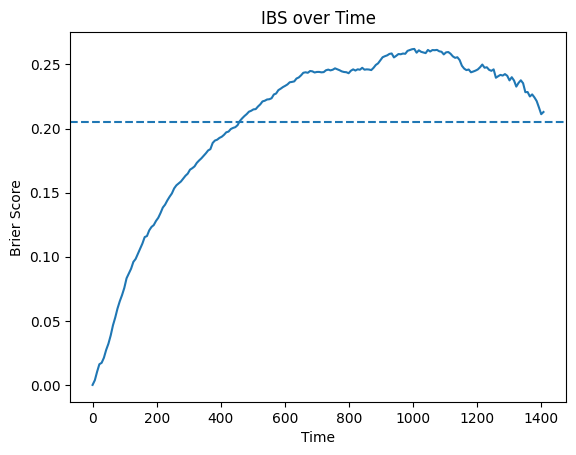

In [79]:
plt.plot(times, ibs_by_time)
plt.axhline(y=mean_ibs, linestyle="--")
plt.title("IBS over Time")
plt.xlabel("Time")
plt.ylabel("Brier Score")
plt.show()

In [80]:
from survivors import metrics
test_df_results = test_df[["name", "episode_col", "dur", "event"]].copy()

test_df_results["dur"] = test_df["dur"] - test_df["entry"]

test_df_results["ibs"] = metrics.ibs(
            survival_train=survival_train,
            survival_test=survival_test,
            estimate=estimate,
            times=times,
            axis=0
        )
test_df_results["auprc"] = metrics.auprc(
            survival_train=survival_train_cens,
            survival_test=survival_test_cens,
            estimate=estimate,
            times=times,
            axis=0
        )

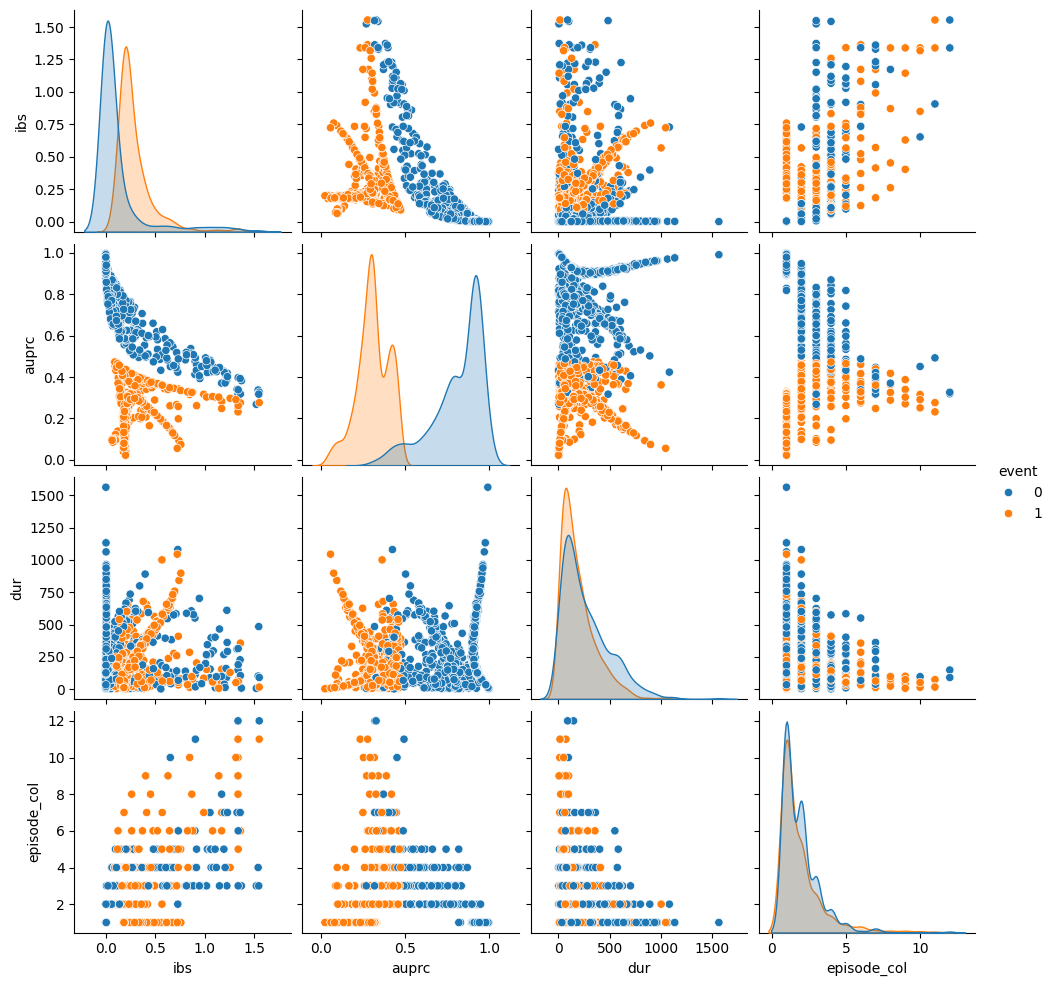

In [81]:
# sns.scatterplot(x="episode_col", y="auprc", data=test_df_results)
sns.pairplot(test_df_results, vars=["ibs", "auprc", "dur", "episode_col"], hue="event")

In [82]:
test_df_results[test_df_results["episode_col"] >= 8].round(3)
# test_df["dur"].describe()

,name,episode_col,dur,event,ibs,auprc
216,brandon ross,8,47.0,1,1.339,0.288
217,brandon ross,9,47.0,1,1.339,0.270
218,brandon ross,10,67.0,1,1.339,0.251
219,brandon ross,11,74.0,1,1.339,0.231
220,brandon ross,12,148.0,0,1.339,0.319
592,eric redmond,8,23.0,1,0.453,0.364
593,eric redmond,9,100.0,1,0.629,0.340
594,eric redmond,10,14.0,1,0.849,0.315
595,eric redmond,11,18.0,0,0.907,0.492
770,jason jaigobin,8,99.0,0,1.173,0.370


<Axes: xlabel='episode_col', ylabel='ibs'>

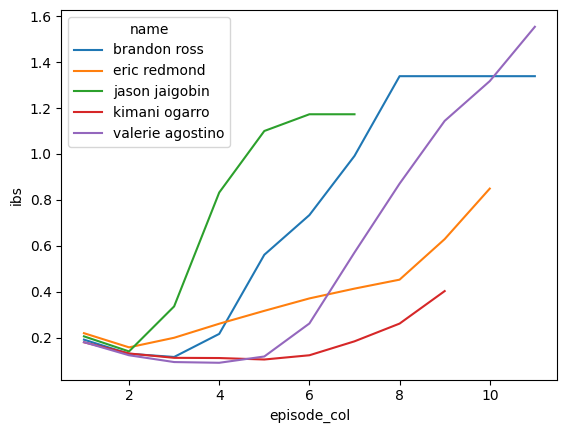

In [83]:
freq_name = test_df_results.query("episode_col >= 8")["name"].unique()
sns.lineplot(x="episode_col", y="ibs", hue="name",
                data=test_df_results.query(f"name.isin({list(freq_name)}) and (event == 1)"))

<Axes: xlabel='episode_col'>

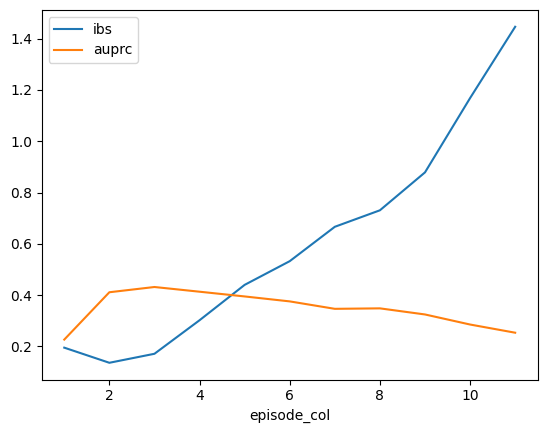

In [84]:
test_df_results.query(f"name.isin({list(freq_name)}) and (event == 1)").groupby("episode_col")[["ibs", "auprc"]].mean().plot()

In [85]:
# tr_pred = 1 - model.predict_survival(train_df, times).values.T
tr_pred = model.predict_cumulative_hazard(train_df, times)
tr_max = np.quantile(tr_pred.max(), 0.95)

# pred = 1 - model.predict_survival(test_df, times).values.T
# test_df.drop_duplicates(["name"], keep='first')
pred = model.predict_cumulative_hazard(test_df, times)
# pred[:] = train_df.groupby("name")["event"].sum().mean()  // baseline случай фиксированного числа событий
print("pred shape:", pred.shape)
print("len(test_df):", len(test_df))
metric = RecurrentCountError()

recurrent_error = metric.compute(
    survival_train=None,
    survival_test=test_df,
    estimate=pred / tr_max,
    times=times
)

mean_events = test_df.groupby("name")["event"].sum().mean()
print("Mean event =", mean_events)
print("Integrated cumulative event error:", recurrent_error)

pred shape: (200, 1623)
len(test_df): 1623
Mean event = 0.9207100591715977
Integrated cumulative event error: 0.2708145327042235


In [86]:
pred

,0,1,2,3,4,5,6,7,8,9,...,1613,1614,1615,1616,1617,1618,1619,1620,1621,1622
0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7.068342,0.000412,0.002918,0.003342,0.002031,0.000496,0.001035,0.001035,0.001035,0.002856,0.002856,...,0.000625,0.003985,0.003985,0.001413,0.000231,0.003689,0.000512,0.002260,0.002697,0.000343
14.136683,0.001425,0.010094,0.011557,0.007025,0.001717,0.003578,0.003578,0.003578,0.009876,0.009876,...,0.002161,0.013781,0.013781,0.004887,0.000800,0.012760,0.001770,0.007817,0.009327,0.001186
21.205025,0.002533,0.017942,0.020544,0.012487,0.003051,0.006361,0.006361,0.006361,0.017556,0.017556,...,0.003841,0.024496,0.024496,0.008687,0.001422,0.022681,0.003146,0.013895,0.016579,0.002107
28.273367,0.003430,0.024295,0.027818,0.016908,0.004132,0.008613,0.008613,0.008613,0.023772,0.023772,...,0.005202,0.033170,0.033170,0.011763,0.001926,0.030711,0.004260,0.018815,0.022449,0.002853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378.326633,0.269509,1.908951,2.185718,1.328514,0.324629,0.676736,0.676736,0.676736,1.867804,1.867804,...,0.408703,2.606277,2.606277,0.924284,0.151335,2.413090,0.334702,1.478387,1.763927,0.224206
1385.394975,0.269770,1.910795,2.187830,1.329798,0.324943,0.677389,0.677389,0.677389,1.869608,1.869608,...,0.409097,2.608794,2.608794,0.925177,0.151481,2.415421,0.335026,1.479815,1.765631,0.224423
1392.463317,0.271370,1.922128,2.200806,1.337685,0.326870,0.681407,0.681407,0.681407,1.880697,1.880697,...,0.411524,2.624268,2.624268,0.930664,0.152380,2.429747,0.337013,1.488592,1.776103,0.225754
1399.531658,0.272979,1.933529,2.213860,1.345619,0.328809,0.685449,0.685449,0.685449,1.891852,1.891852,...,0.413965,2.639833,2.639833,0.936184,0.153284,2.444159,0.339012,1.497421,1.786638,0.227093


In [87]:
test_df.drop_duplicates(["name"], keep='first')

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0.0,699.0,0,25,688.0,11.0,699.0
1,aaron villacampa,1,0.0,107.0,0,26,106.0,1.0,107.0
2,abraham ballestas,1,0.0,35.0,0,52,34.0,1.0,35.0
3,acie canteen,1,0.0,215.0,0,27,214.0,1.0,215.0
4,adam gillstrap,1,0.0,630.0,0,35,628.0,2.0,630.0
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0.0,34.0,0,28,33.0,1.0,34.0
1619,zachary whalen,1,0.0,634.0,0,24,632.0,2.0,634.0
1620,zaheer khan,1,0.0,184.0,0,26,183.0,1.0,184.0
1621,zhivago walker,1,0.0,126.0,0,30,125.0,1.0,126.0
